# Figure 1: Behavior Summary (Due April 20)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

from config import PROJECT_DIR

## 1A: Planning & Extra steps

Steps Extra & Planning Fixations — 3-panel analysis plot \
Left   : Relative frequency of Steps_extra  (0–5, >5 grouped) \
Middle : Relative frequency of plannings    (0–10 individual, 11–15, 16–20, ≥20) \
Right  : Mean plannings ± 95 % CI by Steps_extra group (≤5 only), hue = subject

/var/folders/pv/r3j4sc8s2y3fzzvmn91pxxc80000gn/T/ipykernel_80035/2826271211.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['subject'].replace({"bart": "B", "london": "L"}, inplace=True)


subject
L    5071
B    4543
Name: count, dtype: int64
Saved → /Volumes/Neuro/WallisLab/rotation_EricPlanning/PlanningDynamics/figures_new/fig1A.png


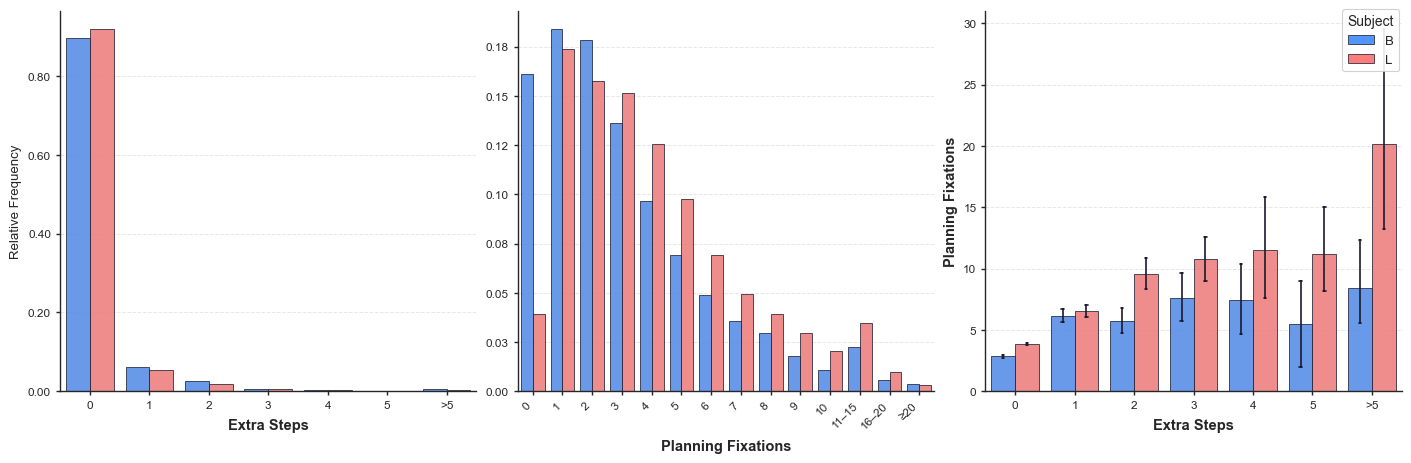

In [5]:
from config import PROJECT_DIR
from fig1 import plot_steps_planning
df = pd.read_pickle(f'{PROJECT_DIR}/behaviordata_v4.pkl')
df['subject'].replace({"bart": "B", "london": "L"}, inplace=True)
df['planningrate'] = df['plannings'].div(df['shortest_path_length'])
print(df['subject'].value_counts())

plot_steps_planning(df)

In [15]:
len(df[(df['subject'] == 'B') & (df['steps_extra'] == 0)]) / len(df[df['subject'] == 'B'])

0.8967642526964561

## 1B: Task Difficulty vs Planning & Extra Steps
Task Complexity : Shortest Path Length, Steps reduced by TP (optimal) / Usage of TP (suboptimal)
Task Bias : path probability (suboptimal: error rate)
number of extra steps are also used for predicting plannings with suboptimal trial


In [ ]:
## Adding decision entropy & path probability
df['optimal'] = (df['steps_extra'] == 0).astype(int)


<Axes: xlabel='teleporter_used_binned', ylabel='plannings'>

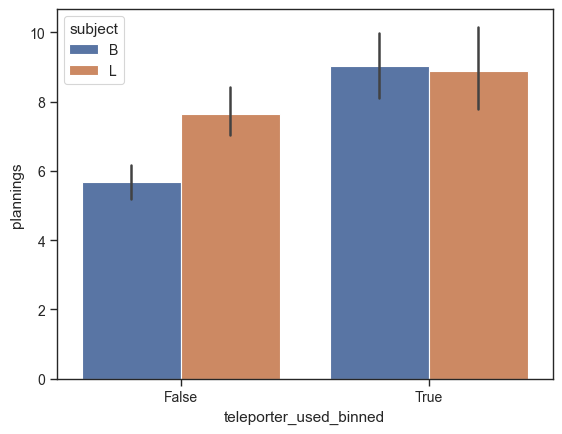

In [73]:
df['teleporter_used_binned'] = df['teleporter_used'] > 0
sns.barplot(data = df[df['steps_extra'] > 0],
            x = 'teleporter_used_binned',
            y = 'plannings',
            hue = 'subject')

In [76]:
df.groupby(by = ['subject','date','nodes'])['shortest_path_length'].count()

subject  date    nodes          
B        031723  0,1                16
                 0,1,2,3,7           2
                 0,1,2,6,10,11,7     1
                 0,15,11,7           6
                 0,15,14            11
                                    ..
L        101124  9,13,14            10
                 9,5,1              14
                 9,5,1,2,3,7         1
                 9,5,6,7             1
                 9,8                15
Name: shortest_path_length, Length: 1895, dtype: int64

In [74]:
df[df['steps_extra'] > 0].teleporter_used.value_counts()

teleporter_used
0    661
1    209
2     11
3      2
Name: count, dtype: int64

<Axes: xlabel='shortest_path_length', ylabel='count'>

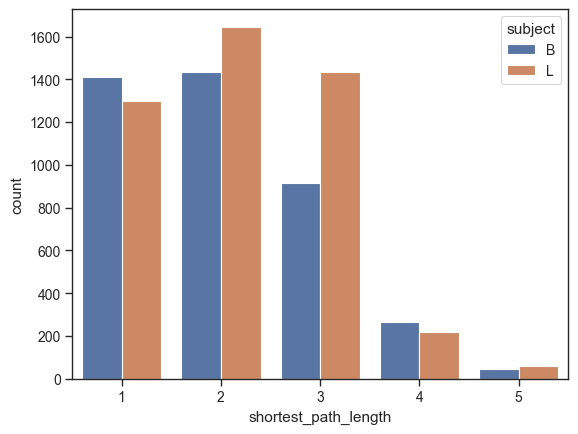

In [ ]:
sns.countplot(data = df[df['steps_extra'] == 0],
              x = 'shortest_path_length',
              hue = 'subject')

In [ ]:
sns.countplot(data = df[df['steps_extra'] == 0],
              x = 'shortest_path_length',
              hue = 'subject')

In [62]:
df[(df['steps_extra'] == 0) & (df['subject'] == 'B')].shortest_path_length.value_counts()

shortest_path_length
2    1435
1    1410
3     917
4     264
5      48
Name: count, dtype: int64

In [69]:
df[(df['subject'] == 'L')].shortest_path_length.value_counts(sort=False)

shortest_path_length
2    1668
1    1300
3    1778
4     255
5      70
Name: count, dtype: int64

In [51]:
df[(df['steps_extra'] == 0) & (df['subject'] == 'B') & (df['shortest_path_length'] == 5)]

,subject,date,start_time,stop_time,trial,trialerror,nsteps,start,target,block,...,shortest_paths,shortest_path_length,steps_teleporter_saved,steps_extra,teleporter_used,plannings,progression,preferred,avg_planning_duration,planningrate
79,B,040423,666038.0,6.764650e+05,112,0.0,5.0,3,8,16.0,...,10,5,0,0,0,17,0.097817,1,231.941176,3.4
184,B,040423,1552492.0,1.560936e+06,266,0.0,5.0,3,8,37.0,...,10,5,0,0,0,7,0.232314,1,329.428571,1.4
228,B,040423,1929742.0,1.937770e+06,332,0.0,5.0,3,8,46.0,...,10,5,0,0,0,8,0.289956,1,187.125000,1.6
234,B,040423,1984873.0,1.993483e+06,341,0.0,5.0,12,7,47.0,...,10,5,0,0,0,6,0.297817,1,277.833333,1.2
351,B,040423,3013143.0,3.020554e+06,521,0.0,5.0,3,8,71.0,...,10,5,0,0,0,9,0.455022,1,156.777778,1.8
521,B,040423,4574207.0,4.581785e+06,796,0.0,5.0,3,8,106.0,...,10,5,0,0,0,5,0.695197,0,234.400000,1.0
545,B,040423,4814956.0,4.822933e+06,841,0.0,5.0,12,7,112.0,...,10,5,0,0,0,8,0.734498,0,170.750000,1.6
578,B,040423,5125279.0,5.132724e+06,892,0.0,5.0,3,8,118.0,...,10,5,0,0,0,4,0.779039,1,124.500000,0.8
581,B,040423,5178077.0,5.185455e+06,901,0.0,5.0,12,7,119.0,...,10,5,0,0,0,12,0.786900,0,70.583333,2.4
592,B,040423,5280025.0,5.290818e+06,919,0.0,5.0,3,8,121.0,...,10,5,0,0,0,16,0.802620,1,246.750000,3.2


In [20]:
df[(df['steps_extra'] > 0) & (df['subject'] == 'B')].shortest_path_length.value_counts()

shortest_path_length
3    354
2     69
1     19
4     17
5     10
Name: count, dtype: int64

In [25]:
df[(df['steps_extra'] > 0) & (df['subject'] == 'L') & (df['shortest_path_length'] == 3)][['nsteps','start','target','nodes','plannings']]

,nsteps,start,target,nodes,plannings
4549,4.0,14,1,"14,10,6,5,1",13
4575,4.0,11,1,"11,7,6,5,1",6
4625,4.0,15,8,"15,14,13,12,8",4
4703,4.0,15,8,"15,14,13,12,8",6
4728,4.0,4,7,"4,0,15,11,7",3
...,...,...,...,...,...
9520,4.0,4,14,"4,8,12,13,14",2
9553,4.0,15,8,"15,14,13,12,8",4
9563,4.0,1,14,"1,5,9,13,14",1
9591,4.0,11,1,"11,10,6,2,1",3


<Axes: xlabel='planningrate', ylabel='Count'>

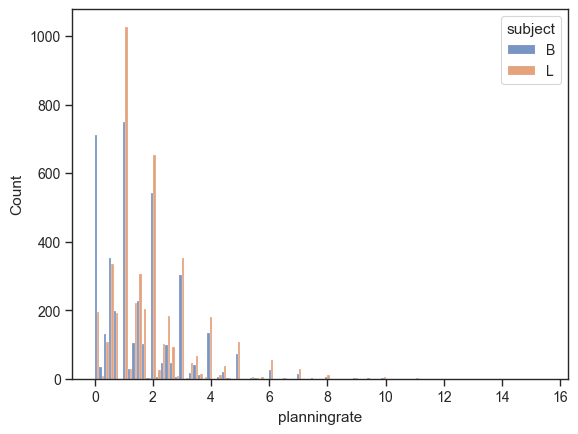

In [34]:
sns.histplot(
    data = df[df['steps_extra'] == 0],
    x = 'planningrate',
    hue = 'subject',
    multiple='dodge'
)

<Axes: >

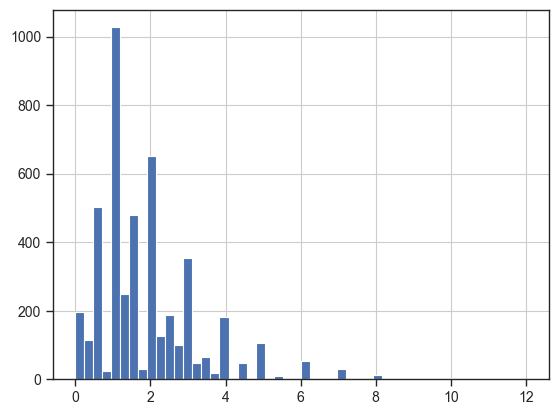

In [46]:
df[(df['steps_extra'] == 0) & (df['subject'] == 'L')].planningrate.hist(bins=50)

<Axes: xlabel='steps_extra', ylabel='plannings'>

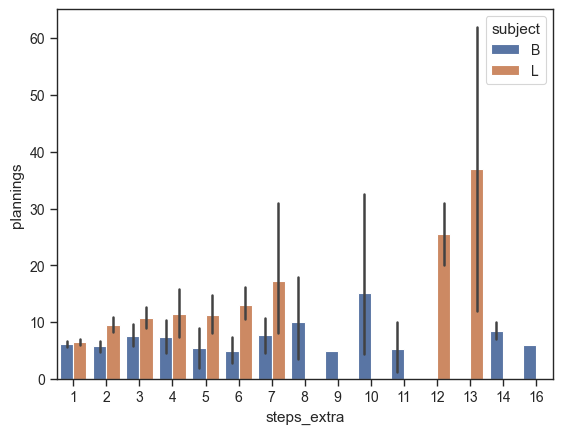

In [47]:
sns.barplot(data = df[df['steps_extra'] > 0],
            x = 'steps_extra',
            y = 'plannings',
            hue = 'subject')

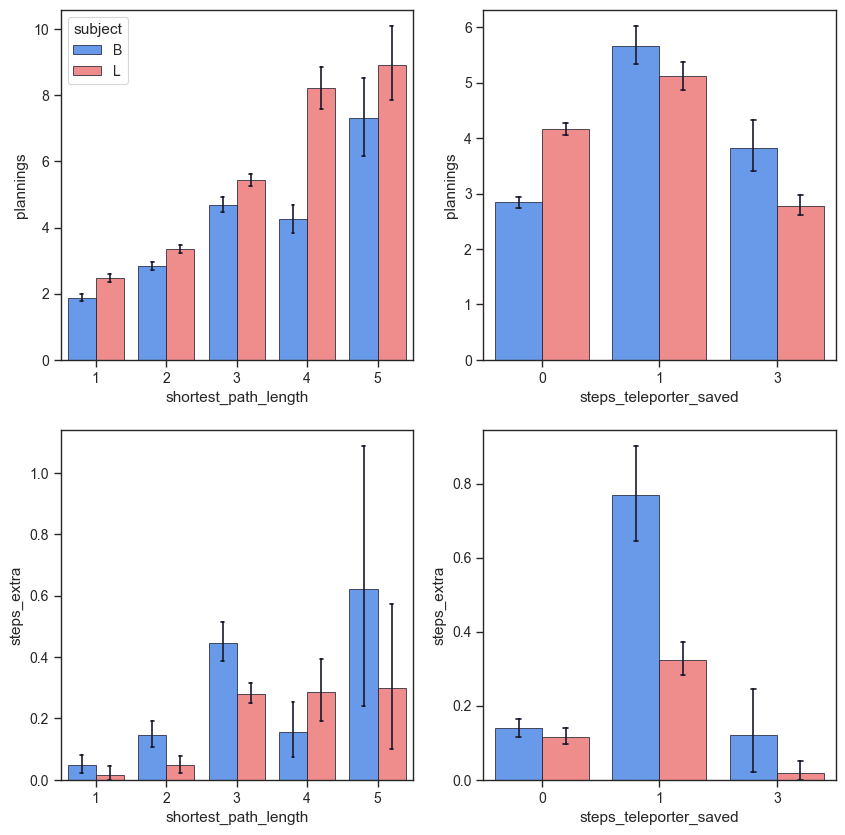

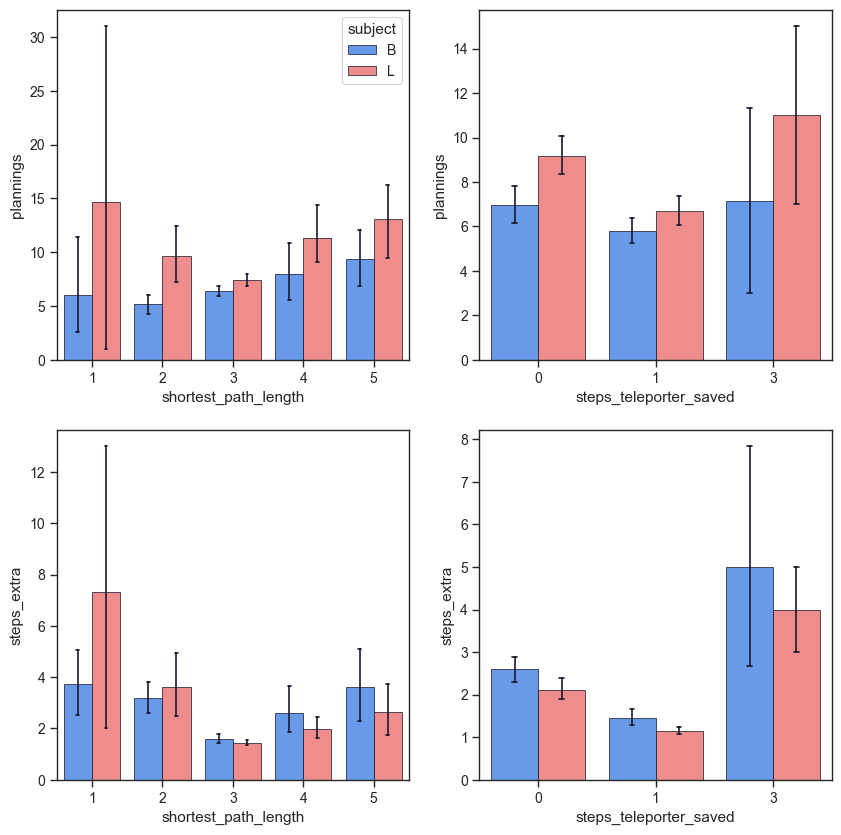

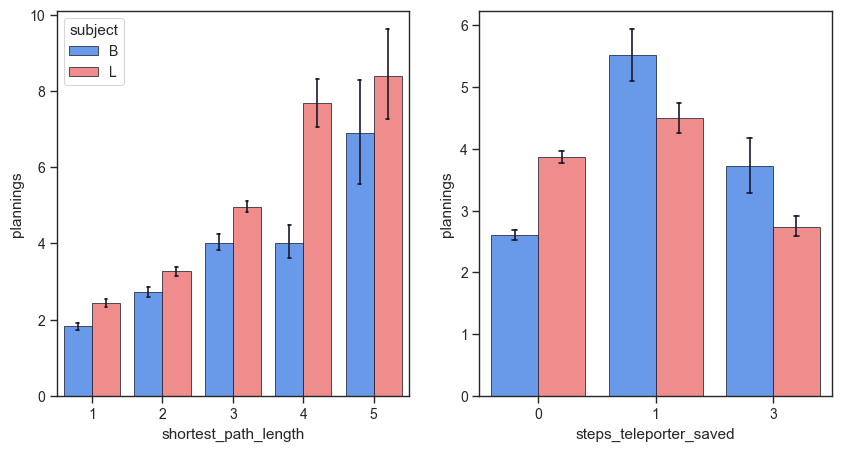

In [4]:
from config import HUE_COL, PALETTE, EDGE_COLOR, GRID_COLOR, STEPS_EXTRA_BINS, PLANNING_BINS
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))

for i, target in enumerate(['plannings','steps_extra']):
    for j, feature in enumerate(['shortest_path_length','steps_teleporter_saved']):
        sns.barplot(
            data=df,
            x=feature, y=target,
            hue=HUE_COL, palette=PALETTE,
            edgecolor=EDGE_COLOR, linewidth=0.6, alpha=0.88,
            errorbar=("ci", 95),
            capsize=0.08,
            err_kws={"linewidth": 1.2, "color": EDGE_COLOR},
            legend=True if (i == 0) & (j == 0) else False,
            ax=axs[i,j],
        )
plt.show()

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))
for i, target in enumerate(['plannings','steps_extra']):
    for j, feature in enumerate(['shortest_path_length','steps_teleporter_saved']):
        sns.barplot(
            data=df[df['steps_extra'] > 0],
            x=feature, y=target,
            hue=HUE_COL, palette=PALETTE,
            edgecolor=EDGE_COLOR, linewidth=0.6, alpha=0.88,
            errorbar=("ci", 95),
            capsize=0.08,
            err_kws={"linewidth": 1.2, "color": EDGE_COLOR},
            legend=True if (i == 0) & (j == 0) else False,
            ax=axs[i,j],
        )
plt.show()

fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 5))
for j, feature in enumerate(['shortest_path_length','steps_teleporter_saved']):
    sns.barplot(
        data=df[df['steps_extra'] == 0],
        x=feature, y='plannings',
        hue=HUE_COL, palette=PALETTE,
        edgecolor=EDGE_COLOR, linewidth=0.6, alpha=0.88,
        errorbar=("ci", 95),
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": EDGE_COLOR},
        legend=True if (j == 0) else False,
        ax=axs[j],
    )
plt.show()
        

## 1B: Path Entropy
L: Definition of path entropy \
R: Duration of plannings vs steps extra

In [1]:
import os
from config import PROJECT_DIR
os.chdir(PROJECT_DIR)
from decision_entropy import nodes_to_list, shannon_entropy, max_entropy
from collections import Counter
import pandas as pd
import numpy as np

In [19]:
path_summary = None
for subject in ['bart','london']:
    df = pd.read_pickle(f"{PROJECT_DIR}/behaviordata_v4.pkl").query("subject == @subject")  # all trials
    #df["nodes"] = df["nodes"].apply(nodes_to_list)
    df = df.dropna(subset=["nodes"])
    
    _df = df.groupby(['subject','start','target','nodes','shortest_path_length','steps_extra']).size().reset_index(name='count')
    _df['subject'] = subject
    _df = _df.reindex(columns=['subject', 'start','target','nodes','shortest_path_length', 'steps_extra','count'])
    df_nodes = df.groupby(['start','target']).size().reset_index(name='task_count')
    dfplanning = df.groupby(["nodes"]).plannings.mean() # calculate mean plannings for each unique path
    _df = _df.merge(df_nodes, on=['start','target'], how='left')
    _df['path_probability'] = _df['count'] / _df['task_count']
    _df = _df.merge(dfplanning.rename('mean_planning'), left_on='nodes', right_index=True, how='left')
    if path_summary is None:
        path_summary = _df
    else:
        path_summary = pd.concat([path_summary, _df], ignore_index=True)
path_summary

df_n_optimal = path_summary[path_summary['steps_extra'] == 0].groupby(['subject','start','target'])['count'].sum().reset_index(name = 'n_optimal')

path_summary = path_summary.merge(df_n_optimal, on = ['subject','start','target'], how = 'left')

path_summary['accuracy'] = path_summary['n_optimal'] / path_summary['task_count']
path_summary['error_rate'] = 1 - path_summary['accuracy']
path_summary

df_suboptimal = path_summary[path_summary['steps_extra'] > 0]

df_suboptimal['n_suboptimal_plannings'] = (df_suboptimal['count'] * df_suboptimal['mean_planning']).astype(int)
_df_suboptimal = df_suboptimal.groupby(['subject','start','target'])[['count','n_suboptimal_plannings']].sum().rename(columns ={'count': 'n_suboptimal', 'n_suboptimal_plannings': 'suboptimal_plannings'})
path_summary = path_summary.merge(_df_suboptimal, on = ['subject','start','target'], how = 'left')
path_summary['suboptimal_plannings'] = path_summary['suboptimal_plannings'].fillna(0)
path_summary['n_suboptimal'] = path_summary['n_suboptimal'].fillna(0)
path_summary['n_suboptimal'] = path_summary['n_suboptimal'].astype(int)
path_summary['suboptimal_plannings'] = path_summary['suboptimal_plannings'].astype(int)

/var/folders/pv/r3j4sc8s2y3fzzvmn91pxxc80000gn/T/ipykernel_61072/4181716593.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_suboptimal['n_suboptimal_plannings'] = (df_suboptimal['count'] * df_suboptimal['mean_planning']).astype(int)


In [21]:
behavior = pd.read_pickle('./behaviordata_v4.pkl')
behavior

,subject,date,start_time,stop_time,trial,trialerror,nsteps,start,target,block,...,nodes,shortest_paths,shortest_path_length,steps_teleporter_saved,steps_extra,teleporter_used,plannings,progression,preferred,avg_planning_duration
0,bart,040423,37297.0,4.028300e+04,2,0.0,1.0,2,1,1.0,...,"2,1",1,1,0,0,0,1,0.001747,0,99.000000
1,bart,040423,41736.0,4.560700e+04,3,0.0,2.0,4,1,1.0,...,"4,5,1",2,2,0,0,0,0,0.002620,1,0.000000
2,bart,040423,47062.0,5.240900e+04,4,0.0,3.0,13,1,1.0,...,"13,9,5,1",1,3,0,0,0,2,0.003493,0,312.500000
3,bart,040423,53862.0,5.833400e+04,5,0.0,2.0,15,1,1.0,...,"15,0,1",1,2,3,0,1,3,0.004367,0,214.666667
4,bart,040423,59787.0,6.445000e+04,6,0.0,2.0,4,1,1.0,...,"4,5,1",2,2,0,0,0,1,0.005240,1,236.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9609,london,100124,5639639.0,5.643553e+06,918,0.0,2.0,2,7,91.0,...,"2,6,7",2,2,0,0,0,3,0.995662,0,94.000000
9610,london,100124,5645004.0,5.654183e+06,919,0.0,3.0,4,7,91.0,...,"4,5,6,7",1,3,0,0,0,16,0.996746,0,231.500000
9611,london,100124,5655634.0,5.659598e+06,920,0.0,1.0,3,7,91.0,...,"3,7",1,1,0,0,0,2,0.997831,0,143.500000
9612,london,100124,5661049.0,5.665380e+06,921,0.0,2.0,10,7,91.0,...,"10,11,7",2,2,0,0,0,3,0.998915,0,59.666667


In [22]:
behavior = behavior.merge(path_summary[['subject','nodes','path_probability','error_rate']], on = ['subject','nodes'], how = 'left')

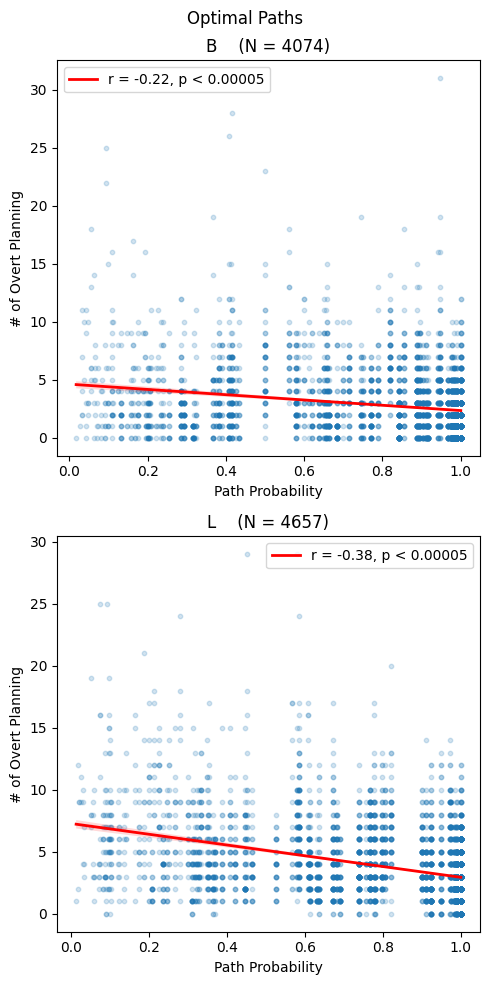

In [ ]:
from scipy.stats import linregress
import matplotlib.pyplot as plt

def p_indicator(pval, alpha = 0.05):
    if pval < alpha * 1e-3:
        pval_return = 'p < 0.00005'
        marker = '****'
    elif pval < alpha * 1e-2:
        pval_return = 'p < 0.0005'
        marker = '***'
    elif pval < alpha * 1e-1:
        pval_return = 'p < 0.005'
        marker = '**'
    elif pval < alpha:
        pval_return = 'p < 0.05'
        marker = '*'
    else:
        pval_return = f'p = {p:.2f}'
        marker = 'n.s.'
    return pval_return, marker
behavior['planningrate'] = behavior['plannings'].div(behavior['shortest_path_length'])
fig, axs = plt.subplots(2, 1, figsize = (5, 10))
for idx, subject in enumerate(['bart','london']):
    data=behavior.query('subject == @subject & steps_extra == 0')

    slope, intercept, r, p, std = linregress(data['path_probability'], data['plannings'])
    pval_return, marker = p_indicator(p)
    sns.regplot(data = data,
                x = 'path_probability', 
                y = 'plannings', x_ci = 'ci', ci = 95,
                marker='o',
                scatter_kws={"s": 10,
                            'alpha': 0.2},
                line_kws={'color': 'red',
                        'linewidth': 2,
                        'label': f'r = {r:.2f}, {pval_return}'},
                ax = axs[idx]
                )
    axs[idx].set_xlabel('Path Probability')
    axs[idx].legend()
    #plt.ylabel('Plannings')
    axs[idx].set_ylabel('# of Overt Planning')
    axs[idx].set_title(f'{subject[0].upper()}    (N = {len(data)})')
plt.suptitle('Optimal Paths')
plt.tight_layout()
plt.show()

In [68]:
## Reaction time 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import os
import glob

from PlanningDynamics import utils, graph
from PlanningDynamics.dataClass import nwbWrapper
from PlanningDynamics.utils import trial_ts
from pingouin import pairwise_tukey, linear_regression

data = nwbWrapper('./data/london/london_092124.nwb', region = 'OFC')
data

loading trial data:
loading trials:


100%|██████████| 897/897 [00:02<00:00, 414.02it/s]


loading choice data:


100%|██████████| 2401/2401 [00:00<00:00, 4632.68it/s]


In [73]:
data.choice_df.query('trial == 2')

,start_time,stop_time,trial,step,trialerror,nsteps,start,target,block,blocktrialnumber,...,node,t_on,graph_distance,spatial_distance,window_size,nodes,timeseries,use_tele,fix_on,fix_off
id,,,,,,,,,,,,,,,,,,,,,
2,51245.5531,52245.5531,2,0,0.0,3.0,6.0,8.0,1.0,3.0,...,6,51745.5531,3,3,500,"6,5,4,8","[(51245, 1000, neural pynwb.base.TimeSeries at...",False,51752,52152
3,52338.3600,53338.3600,2,1,0.0,3.0,6.0,8.0,1.0,3.0,...,5,52838.3600,2,2,500,"6,5,4,8","[(52338, 1000, neural pynwb.base.TimeSeries at...",False,52844,53190
4,54356.7835,55356.7835,2,2,0.0,3.0,6.0,8.0,1.0,3.0,...,4,54856.7835,1,1,500,"6,5,4,8","[(54356, 1000, neural pynwb.base.TimeSeries at...",False,54863,55166
5,55096.4431,56096.4431,2,3,0.0,3.0,6.0,8.0,1.0,3.0,...,8,55596.4431,0,0,500,"6,5,4,8","[(55096, 1000, neural pynwb.base.TimeSeries at...",False,55191,56539


In [74]:
data.fixation_df.query('trial == 2')

,start_time,stop_time,trial_start_time,trial_stop_time,trial,trialerror,nsteps,start,target,block,...,active_prob,step_on,step_off,node_on,node_off,fix_node,entropy_ratio,t_middle,window_size,graph_distance
id,,,,,,,,,,,,,,,,,,,,,
7,51331.0,51477.0,50283.0,57305.9803,2,0.0,3.0,6.0,8.0,1.0,...,0.000000,0.0,0.0,6.0,6.0,12,0.098900,51404.0,500,1
8,51499.0,51722.0,50283.0,57305.9803,2,0.0,3.0,6.0,8.0,1.0,...,0.000000,0.0,0.0,6.0,6.0,8,0.112810,51610.5,500,0
9,51752.0,52152.0,50283.0,57305.9803,2,0.0,3.0,6.0,8.0,1.0,...,0.976667,0.0,1.0,6.0,6.0,6,0.182312,51952.0,500,3
10,52188.0,52544.0,50283.0,57305.9803,2,0.0,3.0,6.0,8.0,1.0,...,0.000000,1.0,1.0,6.0,6.0,8,0.208721,52366.0,500,0
11,52565.0,52814.0,50283.0,57305.9803,2,0.0,3.0,6.0,8.0,1.0,...,0.000000,1.0,1.0,6.0,6.0,12,0.019809,52689.5,500,1
12,52844.0,53190.0,50283.0,57305.9803,2,0.0,3.0,6.0,8.0,1.0,...,0.936667,1.0,1.0,6.0,6.0,5,0.154314,53017.0,500,2
13,53212.0,53471.0,50283.0,57305.9803,2,0.0,3.0,6.0,8.0,1.0,...,0.000000,2.0,2.0,5.0,5.0,4,0.188538,53341.5,500,1
14,53493.0,53845.0,50283.0,57305.9803,2,0.0,3.0,6.0,8.0,1.0,...,0.000000,2.0,2.0,5.0,5.0,8,0.133596,53669.0,500,0
15,53867.0,54134.0,50283.0,57305.9803,2,0.0,3.0,6.0,8.0,1.0,...,0.000000,2.0,2.0,5.0,5.0,4,0.240378,54000.5,500,1


In [71]:
data.trial_df.query('trial == 2')

,start_time,stop_time,trial,trialerror,nsteps,start,target,block,blocktrialnumber,jackpot,nodes
id,,,,,,,,,,,
2,50283.0,57305.9803,2,0.0,3.0,6.0,8.0,1.0,3.0,0,"6,5,4,8"


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── 0. Prepare data ───────────────────────────────────────────────────────────
SUBJECT = 'bart'
#TARGET = 'steps_extra'  # or 'plannings'
CATEGORICAL_FEATURES = ['steps_teleporter_saved']
FEATURES = [
            'shortest_path_length', 
            'plannings', 
            'progression',
            'steps_teleporter_saved'
            'path probability'
            ]

#subject_initial = SUBJECT[0].upper()
df = pd.read_pickle('behaviordata_v4.pkl').query("subject == @SUBJECT & steps_extra == 0")
df = df[df['subject'] == SUBJECT].copy()   

for col in CATEGORICAL_FEATURES:
    df[col] = df[col].astype('category')
    df[col] = pd.Categorical(df[col], categories=sorted(df[col].unique()))

# ── 1. Build design matrices (for discrete models) ───────────────────────────
def build_design_matrix(df, response):
    features = [col for col in FEATURES if col != response]
    X = pd.get_dummies(
        df[features],
        columns=CATEGORICAL_FEATURES,
        drop_first=True,
        dtype=int
    )

    y = df[response].values
    return sm.add_constant(X), X, y, X.columns.tolist()

X_extra_c, X_extra, y_extra, feat_extra = build_design_matrix(
    df, response='steps_extra')

X_plan_c, X_plan, y_plan, feat_plan = build_design_matrix(
    df, response='plannings')

# ── 2. VIF ────────────────────────────────────────────────────────────────────
def compute_vif(X, feature_names):
    vif_df = pd.DataFrame({
        'Feature': feature_names,
        'VIF': [variance_inflation_factor(X.values, i)
                for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False)
    return vif_df

print("=== VIF: Steps_extra model ===")
print(compute_vif(X_extra, feat_extra).to_string(index=False))

print("\n=== VIF: plannings model ===")
print(compute_vif(X_plan, feat_plan).to_string(index=False))

print("\n=== Check for near-zero variance columns (can break Hessian) ===")
print(X_extra.std().sort_values())

print("\n=== Check condition number (> 1000 → severe multicollinearity) ===")
print(f"Condition number: {np.linalg.cond(X_extra_c):.1f}")

print("\n=== Check for any column that is nearly constant ===")
print((X_extra == 0).mean().sort_values())

0.0002120042758733626
0.029909543808900336
0.0002866043265084103
0.07297517280799734
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

london_0 vs. london_1: Custom statistical test, P_val:2.991e-02
bart_0 vs. bart_1: Custom statistical test, P_val:2.120e-04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

london_0 vs. london_1: Custom statistical test, P_val:7.298e-02
bart_0 vs. bart_1: Custom statistical test, P_val:2.866e-04


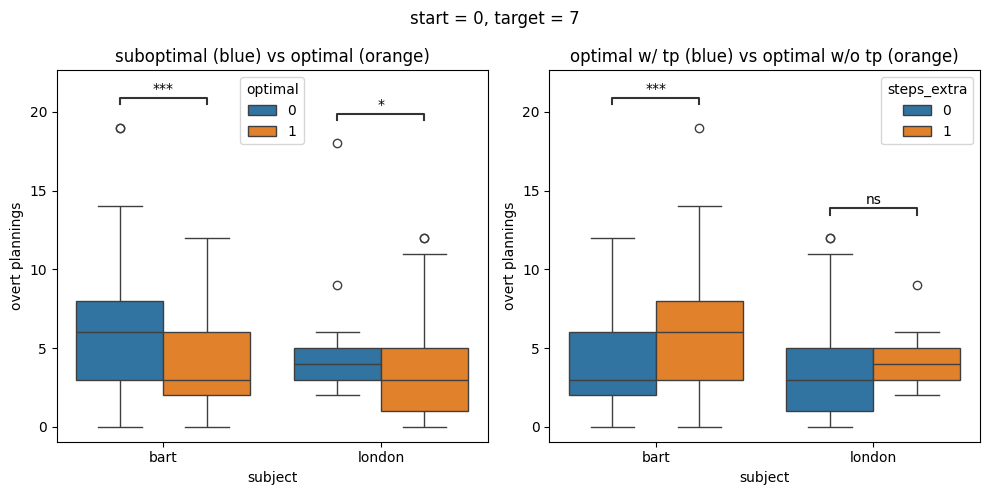

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu

behavior = pd.read_pickle(f"{PROJECT_DIR}/behaviordata_v4.pkl")
behavior['optimal'] = (behavior['steps_extra'] == 0).astype(int)
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 5))
ax1 = sns.boxplot(data = behavior.query('start == 0 & target == 7'),
            x = 'subject',
            y = 'plannings',
            hue = 'optimal',
            ax = axs[0]
)

ax2 = sns.boxplot(data = behavior.query('start == 0 & target == 7 & steps_extra < 2'),
            x = 'subject',
            y = 'plannings',
            hue = 'steps_extra',
            ax = axs[1]
)

def annotate_significance(ax, x1, x2, y, h, p_value):
    """Draw a significance bracket between x1 and x2 at height y."""
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "ns"

    # Draw the bracket
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, color="black")
    ax.text((x1 + x2) / 2, y + h, sig, ha="center", va="bottom", fontsize=12)

_, bart_pval_optimal = mannwhitneyu(
    behavior.query('start == 0 & target == 7 & subject == "bart" & optimal == 1').plannings.values,
    behavior.query('start == 0 & target == 7 & subject == "bart" & optimal == 0').plannings.values,
    alternative='two-sided'
)

_, london_pval_optimal = mannwhitneyu(
    behavior.query('start == 0 & target == 7 & subject == "london" & optimal == 1').plannings.values,
    behavior.query('start == 0 & target == 7 & subject == "london" & optimal == 0').plannings.values,
    alternative='two-sided'
)
print(bart_pval_optimal)
print(london_pval_optimal)

_, bart_pval_euclidean = mannwhitneyu(
    behavior.query('start == 0 & target == 7 & subject == "bart" & steps_extra == 1').plannings.values,
    behavior.query('start == 0 & target == 7 & subject == "bart" & steps_extra == 0').plannings.values,
    alternative='two-sided'
)

_, london_pval_euclidean = mannwhitneyu(
    behavior.query('start == 0 & target == 7 & subject == "london" & steps_extra == 1').plannings.values,
    behavior.query('start == 0 & target == 7 & subject == "london" & steps_extra == 0').plannings.values,
    alternative='two-sided'
)

print(bart_pval_euclidean)
print(london_pval_euclidean)

axs[0].set_title('suboptimal (blue) vs optimal (orange)')
axs[0].set_ylabel('overt plannings')
axs[1].set_title('optimal w/ tp (blue) vs optimal w/o tp (orange)')
axs[1].set_ylabel('overt plannings')
#axs[0].legend_.remove()
#axs[1].legend_.remove()
plt.suptitle('start = 0, target = 7')

# --- Annotate ax1: optimal (0 vs 1) within each subject ---
pairs1 = [
    (("bart",   0), ("bart",   1)),
    (("london", 0), ("london", 1)),
]
annotator1 = Annotator(
    ax1, pairs1,
    data=behavior.query('start == 0 & target == 7'),
    x='subject', y='plannings', hue='optimal'
)
annotator1.configure(text_format='star', loc='inside')
annotator1.set_pvalues_and_annotate([bart_pval_optimal, london_pval_optimal])

# --- Annotate ax2: steps_extra (0 vs 1) within each subject ---
pairs2 = [
    (("bart",   0), ("bart",   1)),
    (("london", 0), ("london", 1)),
]
annotator2 = Annotator(
    ax2, pairs2,
    data=behavior.query('start == 0 & target == 7 & steps_extra < 2'),
    x='subject', y='plannings', hue='steps_extra'
)
annotator2.configure(text_format='star', loc='inside')
annotator2.set_pvalues_and_annotate([bart_pval_euclidean, london_pval_euclidean])

plt.tight_layout()
plt.show()
            

In [ ]:
behavior.query('start == 0 & target == 7 & subject == "bart" & date == "040423"')

In [53]:
## Where do they need to look at?
from PlanningDynamics import utils, graph
from PlanningDynamics.dataClass import nwbWrapper
from PlanningDynamics.utils import trial_ts
from pingouin import pairwise_tukey, linear_regression

current_date = '0'
for idx in behavior.query('start == 0 & target == 7').head().index:
    subject, date, trial, nodes = behavior.loc[idx, ['subject', 'date', 'trial','nodes']]
    if current_date != date:
        nwbfile = f"{PROJECT_DIR}/data/{subject}/{subject}_{date}.nwb"
        data = nwbWrapper(nwbfile, region = 'OFC')
        current_date = date
    df_fixations = data.fixation_df.query('trial == @trial & active_prob <= 0.2')
    
    n_initial_fixations = len(df_fixations.query('step_on <= 1.0'))
    n_initial_fixations_tp = len(df_fixations.query('step_on <= 1.0 & fix_node == 15'))
    n_initial_fixations_goal = len(df_fixations.query('step_on <= 1.0 & fix_node == 7'))
    

loading trial data:
loading trials:


100%|██████████| 996/996 [00:01<00:00, 854.33it/s] 


loading choice data:


100%|██████████| 2452/2452 [00:00<00:00, 5062.50it/s]


In [ ]:
nwbfile = f"{PROJECT_DIR}/data/london/london_100924.nwb"
data = nwbWrapper(nwbfile, region = 'OFC')


loading trial data:
loading trials:


100%|██████████| 910/910 [00:00<00:00, 969.41it/s] 


loading choice data:


100%|██████████| 2434/2434 [00:00<00:00, 3991.77it/s]


TypeError: 'Index' object is not callable

In [ ]:
#329 vs 237
n_initial_fixations = len(data.fixation_df.query('trial == 329 & active_prob <= 0.2 & step_on <= 1.0'))
n_initial_fixations_tp = len(data.fixation_df.query('trial == 329 & active_prob <= 0.2 & step_on <= 1.0 & fix_node == 15'))
n_initial_fixations_goal = len(data.fixation_df.query('trial == 329 & active_prob <= 0.2 & step_on <= 1.0 & fix_node == 7'))

,start_time,stop_time,trial_start_time,trial_stop_time,trial,trialerror,nsteps,start,target,block,...,active_prob,step_on,step_off,node_on,node_off,fix_node,entropy_ratio,t_middle,window_size,graph_distance
id,,,,,,,,,,,,,,,,,,,,,
2210,2185330.0,2185607.0,2184214.0,2.191644e+06,329,0.0,4.0,0.0,7.0,33.0,...,0.0,0.0,0.0,0.0,0.0,0,0.116233,2185468.5,500,3
2211,2185642.0,2185988.0,2184214.0,2.191644e+06,329,0.0,4.0,0.0,7.0,33.0,...,0.0,0.0,0.0,0.0,0.0,7,0.136420,2185815.0,500,0
2212,2186008.0,2186195.0,2184214.0,2.191644e+06,329,0.0,4.0,0.0,7.0,33.0,...,0.0,0.0,0.0,0.0,0.0,3,0.088824,2186101.5,500,1
2215,2186635.0,2187014.0,2184214.0,2.191644e+06,329,0.0,4.0,0.0,7.0,33.0,...,0.0,1.0,1.0,0.0,0.0,7,0.137856,2186824.5,500,0
2216,2187043.0,2187208.0,2184214.0,2.191644e+06,329,0.0,4.0,0.0,7.0,33.0,...,0.0,1.0,1.0,0.0,0.0,15,0.037690,2187125.5,500,2


In [38]:
plt.scatter(_df['path_probability'], _df['mean_planning'], hue=_df['subject'])

NameError: name 'plt' is not defined

In [9]:
records = []
for subject in ['bart','london']:
    df = pd.read_pickle(f"{PROJECT_DIR}/behaviordata_v4.pkl").query("subject == @subject")  # all trials
    df["nodes"] = df["nodes"].apply(nodes_to_list)
    dfplanning = df.groupby(["nodes"]).plannings.mean() # calculate mean plannings for each unique path
    df = df.dropna(subset=["nodes"])
    for (start, target), grp in df.groupby(["start", "target"]):
        path_counts = Counter(grp["nodes"])
        #n_wrong_paths = len(grp[grp['steps_extra'] > 0])
        #path_counts.update({'suboptimal': n_wrong_paths})
        shortest_paths = grp['shortest_paths'].mode()[0]
        shortest_path_length = grp['shortest_path_length'].mode()[0]
        #unique_paths = len(path_counts) 
        
        H = shannon_entropy(path_counts)
        H_max = max_entropy(shortest_paths)
        H_norm = (H / H_max) if H_max > 0 else np.nan
        
        path_dist = {str(list(p)): round (c / (sum(path_counts.values())), 3) for p, c in path_counts.most_common()}        
        planning_dict = {str(list(p)): round(dfplanning[p], 3) for p in path_counts.keys()}
        #planning_dict 
        
        #total_dict = 
        
        #path_counts.update({'suboptimal': n_wrong_paths})
        
        records.append({
            "subject": subject,
            "start": start,
            "target": target,
            "n_trials": sum(path_counts.values()),
            "shortest_paths": shortest_paths,
            #
            # "unique_paths": unique_paths,
            "shortest_path_length": shortest_path_length,
            "H": np.round(H, 4),
            "H_max": np.round(H_max, 4),
            "H_norm": np.round(H_norm, 4),
            "path_dist": path_dist,
            "planning_dist": planning_dict,
            "total_dict": {str(list(p)): {"prob": float(np.round(c / sum(path_counts.values()), 3)), 
                                          "planning": float(np.round(dfplanning[p], 3)), 
                                          "planningrate": float(np.round(dfplanning[p] / (shortest_path_length), 3))} for p, c in path_counts.most_common()}
        })
        #print(start, target, shortest_paths, shortest_path_length, H_norm)
summary = pd.DataFrame(records).sort_values(['subject','start','target'], ascending=True)
summary['subject'].replace({"bart": "B", "london": "L"}, inplace=True)


/var/folders/pv/r3j4sc8s2y3fzzvmn91pxxc80000gn/T/ipykernel_34843/3949608864.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  summary['subject'].replace({"bart": "B", "london": "L"}, inplace=True)


In [ ]:
dict_ex = {'[1,2,3]': 'hi', '[4,5,6]': 'bye'}

In [10]:
summary

,subject,start,target,n_trials,shortest_paths,shortest_path_length,H,H_max,H_norm,path_dist,planning_dist,total_dict
0,B,0,1,126,1,1,0.1842,0.000,NaN,"{'[0, 1]': 0.976, '[0, 4, 5, 1]': 0.016, '[0, ...","{'[0, 1]': 1.537, '[0, 4, 5, 1]': 2.5, '[0, 4,...","{'[0, 1]': {'prob': 0.976, 'planning': 1.537, ..."
1,B,0,7,131,1,3,1.7913,0.000,NaN,"{'[0, 1, 2, 3, 7]': 0.458, '[0, 15, 11, 7]': 0...","{'[0, 15, 11, 7]': 3.88, '[0, 15, 0, 1, 0, 15,...","{'[0, 1, 2, 3, 7]': {'prob': 0.458, 'planning'..."
2,B,0,8,82,1,2,0.6959,0.000,NaN,"{'[0, 4, 8]': 0.902, '[0, 15, 14, 13, 12, 8]':...","{'[0, 4, 8]': 2.514, '[0, 15, 0, 4, 8]': 6.0, ...","{'[0, 4, 8]': {'prob': 0.902, 'planning': 2.51..."
3,B,0,14,114,1,2,0.4160,0.000,NaN,"{'[0, 15, 14]': 0.947, '[0, 1, 0, 15, 14]': 0....","{'[0, 15, 14]': 4.824, '[0, 1, 0, 1, 2, 3, 7, ...","{'[0, 15, 14]': {'prob': 0.947, 'planning': 4...."
4,B,1,7,76,3,3,1.5575,1.585,0.9827,"{'[1, 2, 3, 7]': 0.658, '[1, 2, 6, 7]': 0.158,...","{'[1, 2, 3, 7]': 5.12, '[1, 5, 6, 7]': 5.6, '[...","{'[1, 2, 3, 7]': {'prob': 0.658, 'planning': 5..."
...,...,...,...,...,...,...,...,...,...,...,...,...
114,L,14,8,119,3,3,0.9701,1.585,0.6121,"{'[14, 13, 12, 8]': 0.739, '[14, 13, 9, 8]': 0...","{'[14, 13, 12, 8]': 3.523, '[14, 13, 9, 8]': 3...","{'[14, 13, 12, 8]': {'prob': 0.739, 'planning'..."
115,L,15,1,197,1,2,0.0000,0.000,NaN,"{'[15, 0, 1]': 1.0}","{'[15, 0, 1]': 2.756}","{'[15, 0, 1]': {'prob': 1.0, 'planning': 2.756..."
116,L,15,7,74,1,2,0.1033,0.000,NaN,"{'[15, 11, 7]': 0.986, '[15, 11, 10, 11, 7]': ...","{'[15, 11, 7]': 1.89, '[15, 11, 10, 11, 7]': 2.0}","{'[15, 11, 7]': {'prob': 0.986, 'planning': 1...."
117,L,15,8,194,1,3,0.9818,0.000,NaN,"{'[15, 0, 4, 8]': 0.768, '[15, 14, 13, 12, 8]'...","{'[15, 0, 4, 8]': 4.772, '[15, 14, 13, 12, 8]'...","{'[15, 0, 4, 8]': {'prob': 0.768, 'planning': ..."


In [156]:
for subject in ['bart','london']:
    df = pd.read_pickle(f"{PROJECT_DIR}/behaviordata_v4.pkl").query("steps_extra == 0 & subject == @subject")  # focus on trials with no extra steps
    df["nodes"] = df["nodes"].apply(nodes_to_list)
    df = df.dropna(subset=["nodes"])
    for (start, target), grp in df.groupby(["start", "target"]):
        path_counts = Counter(grp["nodes"])
        plannings = grp['plannings'].mean()
        print(start, target, plannings)

0 1 1.5365853658536586
0 7 3.88
0 8 2.5135135135135136
0 14 4.824074074074074
1 7 4.7611940298507465
1 8 3.108695652173913
1 14 6.813559322033898
2 1 1.024
2 7 3.3875
2 8 5.617647058823529
2 14 5.0476190476190474
3 1 1.9
3 7 2.2844036697247705
3 8 6.8076923076923075
3 14 4.441558441558442
4 1 1.3924050632911393
4 7 5.25531914893617
4 8 1.7758620689655173
4 14 7.7
5 1 1.75
5 7 3.888888888888889
5 8 2.070588235294118
5 14 5.6
6 1 2.8059701492537314
6 7 2.926605504587156
6 8 4.033333333333333
6 14 3.7333333333333334
7 1 3.051282051282051
7 8 4.590909090909091
7 14 2.6944444444444446
8 1 2.4878048780487805
8 7 4.352941176470588
8 14 2.7804878048780486
9 1 2.7288135593220337
9 7 3.727272727272727
9 8 2.3220338983050848
9 14 4.349206349206349
10 1 2.903225806451613
10 7 2.1463414634146343
10 8 2.3380281690140845
10 14 2.753968253968254
11 1 7.666666666666667
11 7 1.280701754385965
11 8 3.409090909090909
11 14 1.945945945945946
12 1 2.8
12 7 7.0
12 8 1.626086956521739
12 14 1.8941176470588235

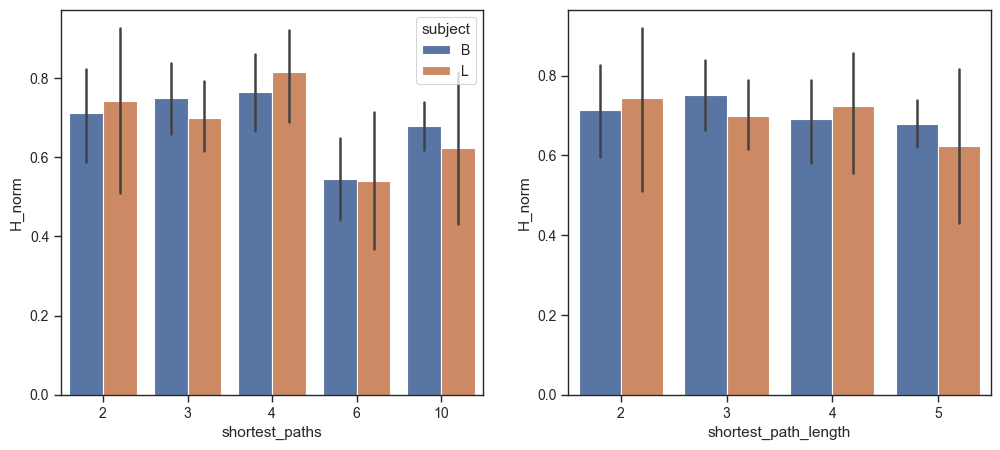

In [50]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=summary[summary['shortest_paths'] > 1], x='shortest_paths', y='H_norm',hue='subject', ax=axs[0])
sns.barplot(data=summary[summary['shortest_paths'] > 1], x='shortest_path_length', y='H_norm',hue='subject', ax=axs[1])
axs[1].get_legend().remove()
plt.show()

In [52]:
import scipy.stats as stats
data=summary[(summary['shortest_paths'] > 1) & (summary['subject'] == 'L')]
f_stat, p_val = stats.f_oneway(data.query('shortest_path_length == 2').H_norm, 
                               data.query('shortest_path_length == 3').H_norm,
                               data.query('shortest_path_length == 4').H_norm)
print(f_stat, p_val)

0.08470136315393088 0.919084767453527


In [29]:
summary.shortest_path_length.value_counts()

shortest_path_length
3    43
2    36
1    24
4    12
5     4
Name: count, dtype: int64

In [158]:
summary[summary['shortest_paths'] == 3]['total_dict'].values

array([{'[1, 2, 3, 7]': {'prob': 0.746, 'planning': 5.12, 'planningrate': 1.707}, '[1, 2, 6, 7]': {'prob': 0.179, 'planning': 2.917, 'planningrate': 0.972}, '[1, 5, 6, 7]': {'prob': 0.075, 'planning': 5.6, 'planningrate': 1.867}},
       {'[1, 0, 4, 8]': {'prob': 0.457, 'planning': 4.333, 'planningrate': 1.444}, '[1, 5, 4, 8]': {'prob': 0.326, 'planning': 2.6, 'planningrate': 0.867}, '[1, 5, 9, 8]': {'prob': 0.217, 'planning': 1.3, 'planningrate': 0.433}},
       {'[5, 9, 13, 14]': {'prob': 0.64, 'planning': 3.625, 'planningrate': 1.208}, '[5, 6, 10, 14]': {'prob': 0.24, 'planning': 4.833, 'planningrate': 1.611}, '[5, 9, 10, 14]': {'prob': 0.12, 'planning': 17.667, 'planningrate': 5.889}},
       {'[6, 5, 4, 8]': {'prob': 0.683, 'planning': 4.0, 'planningrate': 1.333}, '[6, 5, 9, 8]': {'prob': 0.25, 'planning': 3.733, 'planningrate': 1.244}, '[6, 10, 9, 8]': {'prob': 0.067, 'planning': 5.5, 'planningrate': 1.833}},
       {'[7, 6, 2, 1]': {'prob': 0.436, 'planning': 2.824, 'planningrat

In [31]:
prob = list()
planningrate = list()
spaths = list()
subjects = list()
for idx in summary[summary['shortest_paths'] > 1].index:
    subject, shortest_paths = summary.loc[idx, ['subject','shortest_paths']]
    probdict = summary.loc[idx, 'total_dict']
    for path, values in probdict.items():
        subjects.append(subject)
        prob.append(values['prob'])
        planningrate.append(values['planningrate'])
        spaths.append(shortest_paths)
mini_df = pd.DataFrame({'Subject': subjects,
                        'Path Probability': prob,
                        'Planning Rate': planningrate,
                        'Shortest Paths': spaths})
    
    

=== VIF: Steps_extra model ===


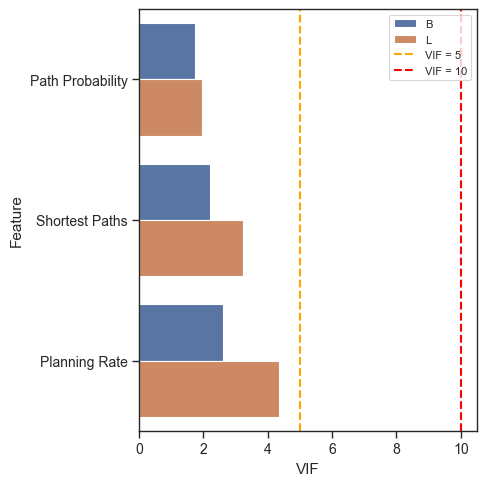

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# ── 2. VIF ────────────────────────────────────────────────────────────────────
def compute_vif(X, feature_names):
    vif_df = pd.DataFrame({
        'Feature': feature_names,
        'VIF': [variance_inflation_factor(X.values, i)
                for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False)
    return vif_df
preference_features = ['Path Probability','Planning Rate','Shortest Paths']
print("=== VIF: Steps_extra model ===")
vif_full_df = None
for subject in ['B', 'L']:
    vif = compute_vif(mini_df[mini_df['Subject'] == subject].drop(['Subject'], axis = 1), preference_features)
    vif['Subject'] = subject
    if vif_full_df is None:
        vif_full_df = vif.copy()
    else:
        vif_full_df = pd.concat((vif_full_df, vif), axis = 0)

#vif_L = compute_vif(mini_df.query('subject == L'), preference_features)
fig, ax = plt.subplots(figsize=(5, 5))

vif_sorted = vif_full_df.sort_values('VIF', ascending=True)
colors = ['#d62728' if v > 5 else 'steelblue' for v in vif_sorted['VIF']]
#sns.barplot
#ax.barh(vif_sorted['Feature'], vif_sorted['Feature'],
#        color=colors, edgecolor='black', height=0.6, hue='Subject')
sns.barplot(x='VIF', y='Feature', data = vif_sorted, orient='h', hue = 'Subject', ax=ax)
ax.axvline(x=5,  color='orange', linestyle='--', lw=1.5, label='VIF = 5')
ax.axvline(x=10, color='red',    linestyle='--', lw=1.5, label='VIF = 10')
ax.set_xlabel('VIF')
ax.legend(fontsize=8)
#plt.suptitle('Variance Inflation Factor by Model', fontweight='bold')
plt.tight_layout()
#plt.savefig(f'vif_barplot_{SUBJECT}.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
mini_df

,Subject,Path Probability,Planning Rate,Shortest Paths
0,B,0.746,1.707,3
1,B,0.179,0.972,3
2,B,0.075,1.867,3
3,B,0.457,1.444,3
4,B,0.326,0.867,3
...,...,...,...,...
168,L,0.690,1.163,2
169,L,0.310,1.159,2
170,L,0.746,1.174,3
171,L,0.237,1.262,3


In [20]:
prob

[0.746,
 0.179,
 0.075,
 0.457,
 0.326,
 0.217,
 0.9,
 0.1,
 0.441,
 0.412,
 0.059,
 0.059,
 0.029,
 0.269,
 0.231,
 0.192,
 0.192,
 0.038,
 0.038,
 0.038,
 0.442,
 0.39,
 0.117,
 0.052,
 0.684,
 0.316,
 0.694,
 0.306,
 0.64,
 0.24,
 0.12,
 0.746,
 0.254,
 0.683,
 0.25,
 0.067,
 0.436,
 0.385,
 0.179,
 0.636,
 0.227,
 0.136,
 0.75,
 0.167,
 0.083,
 0.634,
 0.293,
 0.073,
 0.647,
 0.235,
 0.059,
 0.059,
 0.439,
 0.341,
 0.22,
 0.818,
 0.182,
 0.714,
 0.286,
 0.516,
 0.387,
 0.097,
 0.902,
 0.098,
 0.865,
 0.135,
 0.435,
 0.306,
 0.141,
 0.118,
 0.5,
 0.182,
 0.136,
 0.091,
 0.045,
 0.045,
 0.724,
 0.207,
 0.034,
 0.034,
 0.794,
 0.206,
 0.698,
 0.256,
 0.047,
 0.745,
 0.235,
 0.02,
 0.358,
 0.34,
 0.302,
 0.75,
 0.176,
 0.074,
 0.635,
 0.365,
 0.462,
 0.231,
 0.231,
 0.051,
 0.026,
 0.286,
 0.229,
 0.114,
 0.114,
 0.086,
 0.086,
 0.057,
 0.029,
 0.375,
 0.3,
 0.175,
 0.15,
 0.671,
 0.329,
 0.987,
 0.013,
 0.825,
 0.105,
 0.07,
 0.63,
 0.37,
 0.8,
 0.1,
 0.1,
 0.596,
 0.365,
 0.038,
 0.4

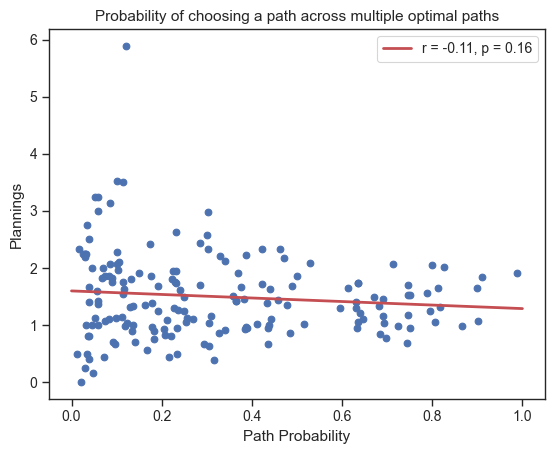

In [21]:
from scipy.stats import linregress
plt.scatter(prob, planningrate)
slope, intercept, r, p, std = linregress(prob, planningrate)

plt.xlabel('Path Probability')
plt.ylabel('Plannings')
#plt.ylabel('Planning rate (Planning / shortest path length)')
plt.plot(np.linspace(0, 1, 50), slope * np.linspace(0, 1, 50) + intercept, label = f'r = {r:.2f}, p = {p:.2f}', color = 'r', linewidth = 2)
plt.legend()
plt.title('Probability of choosing a path across multiple optimal paths')
plt.show()

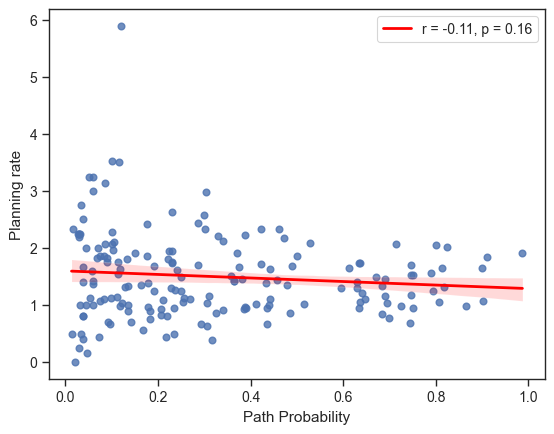

In [23]:
slope, intercept, r, p, std = linregress(prob, planningrate)

sns.regplot(x = prob, 
            y = planningrate, x_ci = 'ci', ci = 95,
            marker='o',
            line_kws={'color': 'red',
                      'linewidth': 2,
                      'label': f'r = {r:.2f}, p = {p:.2f}'},
            )
plt.legend()
plt.xlabel('Path Probability')
#plt.ylabel('Plannings')
plt.ylabel('Planning rate')
plt.show()